## 1. Data Quality Check 목적

본 노트북은 Brazilian E-Commerce Public Dataset(Olist)의
데이터 품질을 점검하고,
이후 분석(ARR, Retention, LTV)에 앞서
공통으로 적용할 전처리 기준을 정의하는 것을 목표로 한다.

[1-1] 데이터 로드 & 기본 정보 확인

In [26]:
# [1-0] 라이브러리 불러오기 & 출력 옵션
# - pandas: 표 형태 데이터 처리
# - numpy: 수치 계산/결측 처리에 자주 사용

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [27]:
# [1-1] 데이터 로드 (Raw CSV)
# - read_csv(): CSV 파일을 DataFrame으로 읽어옴
# - parse_dates: 지정한 컬럼을 datetime으로 자동 변환(시간 분석 필수)

base_path = "../data/raw/"

customers = pd.read_csv(base_path + "olist_customers_dataset.csv")
orders = pd.read_csv(
    base_path + "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)
payments = pd.read_csv(base_path + "olist_order_payments_dataset.csv")
items = pd.read_csv(
    base_path + "olist_order_items_dataset.csv",
    parse_dates=["shipping_limit_date"]
)
reviews = pd.read_csv(
    base_path + "olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"]
)

print("✅ Loaded tables:")
print("customers:", customers.shape)
print("orders   :", orders.shape)
print("payments :", payments.shape)
print("items    :", items.shape)
print("reviews  :", reviews.shape)

✅ Loaded tables:
customers: (99441, 5)
orders   : (99441, 8)
payments : (103886, 5)
items    : (112650, 7)
reviews  : (99224, 7)


✅ 데이터 품질 판정  

	•	테이블 누락 없음
	•	주문/결제/아이템 구조 정상
	•	고객-주문 관계 명확
	•	분석 불가 수준의 이상 없음

 
➡️ 01_data_quality_check.ipynb 기준으로는 통과

Olist 데이터는 주문 단위로 설계된 이커머스 데이터셋으로, <br>
하나의 고객(customer_unique_id)은 여러 주문(customer_id)을 가질 수 있다.<br>
결제(payments)와 상품(items)은 주문 단위에서 다대일 관계를 가지므로,<br>
분석 목적에 따라 주문 단위 집계가 필요


In [28]:
# [1-2] 기본 스키마(컬럼/타입) 점검
# - info(): 결측치 수, dtype 확인
# - 이후 join/집계/시간분석에서 dtype이 틀어지면 사고남

def quick_info(df, name):
    print(f"\n--- {name} ---")
    display(df.head(3))
    df.info()

quick_info(customers, "customers")
quick_info(orders, "orders")
quick_info(payments, "payments")
quick_info(items, "items")
quick_info(reviews, "reviews")


--- customers ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

--- orders ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB

--- payments ---


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB

--- items ---


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9000,13.2900
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9000,19.9300
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0000,17.8700


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB

--- reviews ---


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [29]:
# [1-3] Key(식별자) 유니크/중복 점검
# - nunique(): 중복 제거 후 유니크 개수
# - is_unique: 완전 유니크인지 True/False
# - 분석에서 "주문 단위 key"는 order_id, "고객 단위 key"는 customer_unique_id가 핵심

checks = pd.DataFrame({
    "table": ["customers", "orders", "payments", "items", "reviews"],
    "row_count": [len(customers), len(orders), len(payments), len(items), len(reviews)],
    "order_id_nunique": [
        np.nan,
        orders["order_id"].nunique(),
        payments["order_id"].nunique(),
        items["order_id"].nunique(),
        reviews["order_id"].nunique(),
    ],
    "customer_id_nunique": [
        customers["customer_id"].nunique(),
        orders["customer_id"].nunique(),
        np.nan, np.nan, np.nan
    ],
    "customer_unique_id_nunique": [
        customers["customer_unique_id"].nunique(),
        np.nan, np.nan, np.nan, np.nan
    ],
})

checks

,table,row_count,order_id_nunique,customer_id_nunique,customer_unique_id_nunique
0,customers,99441,NaN,99441.0000,96096.0000
1,orders,99441,99441.0000,99441.0000,NaN
2,payments,103886,99440.0000,NaN,NaN
3,items,112650,98666.0000,NaN,NaN
4,reviews,99224,98673.0000,NaN,NaN


✅ (1) 데이터 품질 문제 ❌
	•	PK 깨짐 없음
	•	비정상 중복 없음
	•	설명 불가능한 결측 없음

👉 “데이터가 이상해서 결과가 이렇게 나온 건 아니다”를 증명

⸻

✅ (2) 리텐션 분석의 전제는 이미 보인다
	•	customers:
	•	customer_id 99,441
	•	customer_unique_id 96,096

👉 이미 여기서

“같은 사람이 여러 번 구매하긴 하지만, 그 비율은 크지 않다”
라는 신호가 있음

## 📌 데이터 품질 점검 요약 (Data Quality Check)

- customers, orders, payments, items, reviews 테이블의 기본 row 수 및 유니크 구조를 점검한 결과,  
  **Olist 데이터는 구조적으로 정상적인 이커머스 데이터셋임을 확인하였다.**

- payments와 items 테이블에서 order_id 기준 중복이 존재하는 것은  
  **한 주문에 여러 결제(payment) 및 여러 상품(item)이 포함될 수 있는 정상적인 이커머스 구조**에 기인한다.

- 고객 분석 시에는 주문 단위 식별자인 `customer_id`가 아닌,  
  **실제 고객을 의미하는 `customer_unique_id`를 기준으로 분석해야 함을 확인하였다.**

- 본 프로젝트에서는 이후 모든 분석의 기준을 아래와 같이 통일한다.
  - **배송 완료(`delivered`) 주문 기준**
  - **`customer_unique_id` 기준 고객 단위**
  - **월(Month) 단위 시간 집계**

In [43]:
# [1-3-1] 주문 상태별 건수 및 비율 계산
# - value_counts(): 각 상태별 개수 집계
# - normalize=True: 비율 계산
# - reset_index(): DataFrame 형태로 변환

order_status_summary = (
    orders["order_status"]
    .value_counts(normalize=False)
    .to_frame(name="count")
)

order_status_summary["ratio(%)"] = (
    order_status_summary["count"] / order_status_summary["count"].sum() * 100
)

order_status_summary

,count,ratio(%)
order_status,,
delivered,96478,97.0203
shipped,1107,1.1132
canceled,625,0.6285
unavailable,609,0.6124
invoiced,314,0.3158
processing,301,0.3027
created,5,0.0050
approved,2,0.0020


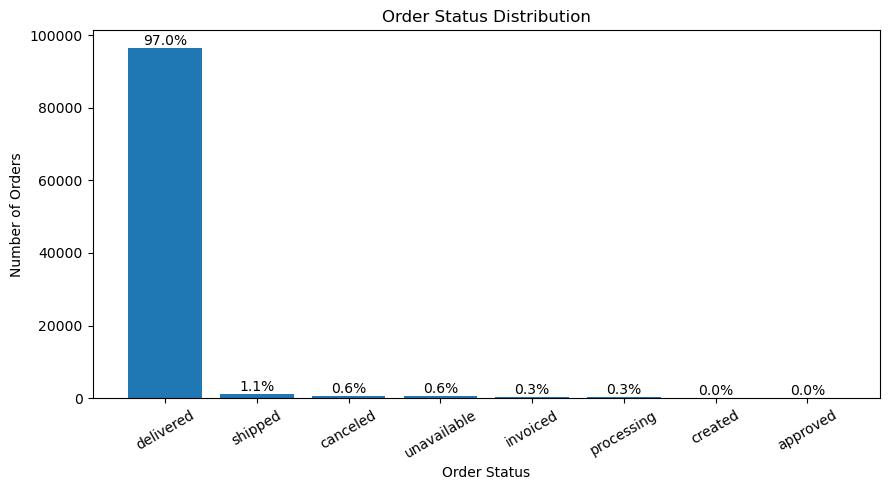

In [44]:
# [1-3-2] 주문 상태 분포 시각화
# - 분석 기준 설명용 차트
# - delivered가 압도적임을 보여주기

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    order_status_summary.index,
    order_status_summary["count"]
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

# x축 라벨 겹침 방지
plt.xticks(rotation=30)

# 각 막대 위에 비율 표시
for idx, (count, ratio) in enumerate(
    zip(order_status_summary["count"], order_status_summary["ratio(%)"])
):
    plt.text(
        idx,
        count,
        f"{ratio:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

- 전체 주문의 약 97%가 배송 완료(delivered) 상태로,
  이후 모든 분석을 delivered 주문 기준으로 제한하더라도
  데이터 대표성에는 문제가 없다.

Olist 데이터는 2016년 9월부터 2018년 10월까지 약 2년간의 고객 행동을 관측할 수 있으며,
리텐션·코호트 분석에서는 주문 시점(order_purchase_timestamp)을 기준으로,
배송 완료(delivered) 주문만을 활성 고객으로 정의하는 것이 가장 일관된 기준이다

In [46]:
# [1-5] 주문 데이터 관측 기간 요약 테이블
# 목적:
# - 주문 데이터의 시간 범위를 한 눈에 확인
# - 관측 기간(analysis window) 합의의 근거 자료로 사용

date_cols = {
    "order_purchase_timestamp": "주문 시점 (구매)",
    "order_approved_at": "결제 승인 시점",
    "order_delivered_carrier_date": "배송 시작 시점",
    "order_delivered_customer_date": "배송 완료 시점",
    "order_estimated_delivery_date": "예상 배송일"
}

# pandas 개념:
# - min(), max(): 컬럼의 최소/최대값
# - DataFrame(list of dict): 행 단위로 표 생성

date_range_summary = pd.DataFrame([
    {
        "date_column": col,
        "description": desc,
        "start_date": orders[col].min(),
        "end_date": orders[col].max()
    }
    for col, desc in date_cols.items()
])

date_range_summary["start_date"] = date_range_summary["start_date"].dt.date
date_range_summary["end_date"] = date_range_summary["end_date"].dt.date

date_range_summary



,date_column,description,start_date,end_date
0,order_purchase_timestamp,주문 시점 (구매),2016-09-04,2018-10-17
1,order_approved_at,결제 승인 시점,2016-09-15,2018-09-03
2,order_delivered_carrier_date,배송 시작 시점,2016-10-08,2018-09-11
3,order_delivered_customer_date,배송 완료 시점,2016-10-11,2018-10-17
4,order_estimated_delivery_date,예상 배송일,2016-09-30,2018-11-12


#### Day 0   : 주문
#### Day 5~10: 배송 시작
#### Day 10~20: 배송 완료 (Activation 기준)
#### Day 20~40: 상품 사용 / 경험
#### Day 30~60: 재구매 고려

In [32]:
# [1-6] 결측치(NA) 점검: 전체 테이블 요약
# - isna().mean(): 결측 비율
# - 정렬해서 "문제 큰 컬럼"부터 본다

def na_ratio(df, name, top_n=10):
    s = (df.isna().mean() * 100).sort_values(ascending=False)
    print(f"\n--- {name} NA ratio top {top_n} ---")
    display(s.head(top_n).to_frame("na_ratio(%)"))

na_ratio(customers, "customers")
na_ratio(orders, "orders")
na_ratio(payments, "payments")
na_ratio(items, "items")
na_ratio(reviews, "reviews")


--- customers NA ratio top 10 ---


,na_ratio(%)
customer_id,0.0000
customer_unique_id,0.0000
customer_zip_code_prefix,0.0000
customer_city,0.0000
customer_state,0.0000



--- orders NA ratio top 10 ---


,na_ratio(%)
order_delivered_customer_date,2.9817
order_delivered_carrier_date,1.7930
order_approved_at,0.1609
order_id,0.0000
customer_id,0.0000
order_status,0.0000
order_purchase_timestamp,0.0000
order_estimated_delivery_date,0.0000



--- payments NA ratio top 10 ---


,na_ratio(%)
order_id,0.0000
payment_sequential,0.0000
payment_type,0.0000
payment_installments,0.0000
payment_value,0.0000



--- items NA ratio top 10 ---


,na_ratio(%)
order_id,0.0000
order_item_id,0.0000
product_id,0.0000
seller_id,0.0000
shipping_limit_date,0.0000
price,0.0000
freight_value,0.0000



--- reviews NA ratio top 10 ---


,na_ratio(%)
review_comment_title,88.3415
review_comment_message,58.7025
review_id,0.0000
order_id,0.0000
review_score,0.0000
review_creation_date,0.0000
review_answer_timestamp,0.0000


### 결측 관련해서 중요한 컬럼(오더테이블에서 일단 주문상태에서 결측이 조금 있으나 delivered 필터링 단계에서 자연스럽게 제거됨)은 괜찮고, 리뷰 부분만 자연스러운 결측이 확인됨. <br>
	•	리뷰 텍스트 컬럼의 결측은 사용자 입력 여부에 따른 자연스러운 결측
	•	평점(review_score)과 리뷰 ID는 100% 존재 → 리뷰 데이터 자체는 신뢰 가능

📌 처리 원칙
	•	리뷰 정량 분석(평점) 에서는 결측 처리 불필요
	•	리뷰 텍스트 분석(NLP) 시에만 결측 제거 또는 별도 처리

### 결측치(Missing Value) 점검 결과

- reviews 테이블의 텍스트 컬럼(review_comment_title, review_comment_message)은
  사용자 선택 입력 필드로, 높은 결측 비율은 정상적인 현상이다.
- 리뷰 평점(review_score) 및 식별자 컬럼은 결측이 없어
  리뷰 데이터는 정량 분석에 활용 가능한 상태임을 확인하였다.

- orders 테이블의 일부 날짜 컬럼에서 결측이 존재하나,
  이는 배송 전/취소/처리 중 주문에 해당하며
  주문 상태(order_status)와 논리적으로 일관된 결측이다.

- 본 프로젝트에서는 배송 완료(delivered) 주문만을 분석 대상으로 사용하므로,
  해당 결측치는 분석 과정에서 자연스럽게 제외된다.

📌 결론적으로 Olist 데이터셋은
비즈니스 흐름상 설명 가능한 결측만 존재하는
구조적으로 신뢰 가능한 이커머스 데이터임을 확인하였다.

In [34]:
# [1-8] payment_value 이상치 스캔
# - describe(): 기본 통계량
# - 상위 0.1% 등 극단치 확인 (LTV 왜곡 가능성 체크)
# - 아직 제거하지 말고 '존재 여부'와 '추후 처리 옵션'을 문서화

payments["payment_value"].describe()

count   103886.0000
mean       154.1004
std        217.4941
min          0.0000
25%         56.7900
50%        100.0000
75%        171.8375
max      13664.0800
Name: payment_value, dtype: float64

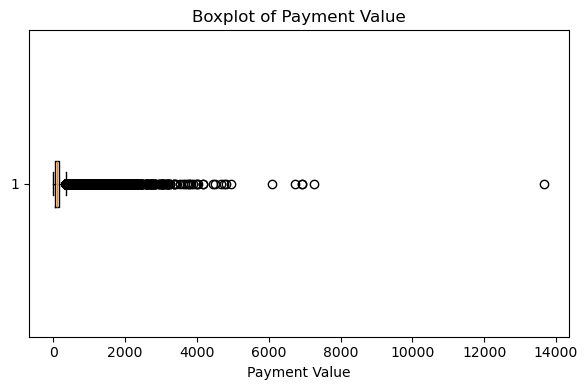

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.boxplot(
    payments["payment_value"],
    vert=False,
    showfliers=True
)

plt.title("Boxplot of Payment Value")
plt.xlabel("Payment Value")

plt.tight_layout()
plt.show()

### 결제 금액 분포 및 이상치 점검

- 결제 금액(payment_value)은 중앙값 약 100 수준으로,
  대부분의 주문은 낮은 금액대에 집중되어 있다.
- 그러나 일부 주문에서 1,000 이상, 최대 약 13,600 수준의
  고액 결제가 존재함을 박스플롯을 통해 확인하였다.
- 이로 인해 평균 기반 지표(ARPU, LTV)는
  소수의 극단값에 의해 왜곡될 가능성이 있다.

📌 본 단계에서는 이상치를 제거하지 않으며,
이후 고객 단위 분석 단계에서
- 로그 스케일,
- 상위 퍼센타일 기준 분석,
- 또는 별도 고액 고객 분리 분석 여부를 검토한다.

In [35]:
# [1-8-1] payment_value 상위 극단치 몇 개 확인 (눈으로 보기)
# - sort_values: 큰 값부터 보기
# - head: 상위 N개 확인

payments.sort_values("payment_value", ascending=False).head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
52107,03caa2c082116e1d31e67e9ae3700499,1,credit_card,1,13664.0800
34370,736e1922ae60d0d6a89247b851902527,1,boleto,1,7274.8800
41419,0812eb902a67711a1cb742b3cdaa65ae,1,credit_card,8,6929.3100
49581,fefacc66af859508bf1a7934eab1e97f,1,boleto,1,6922.2100
85539,f5136e38d1a14a4dbd87dff67da82701,1,boleto,1,6726.6600
62409,2cc9089445046817a7539d90805e6e5a,1,boleto,1,6081.5400
43232,a96610ab360d42a2e5335a3998b4718a,1,credit_card,10,4950.3400
70320,b4c4b76c642808cbe472a32b86cddc95,1,credit_card,5,4809.4400
6440,199af31afc78c699f0dbf71fb178d4d4,1,credit_card,8,4764.3400
67546,8dbc85d1447242f3b127dda390d56e19,1,credit_card,8,4681.7800


In [36]:
# [1-9] 주문 1건에 결제가 여러 행 존재하는지 확인 (payment_sequential 관련)
# - groupby().size(): 주문별 결제 row 개수
# - 최대값이 크면 "order 단위로 합산(sum)"이 필요하다는 근거가 됨

pay_rows_per_order = payments.groupby("order_id").size()

print("결제 row 수(주문별) 요약:")
display(pay_rows_per_order.describe())

print("\n주문 1건당 결제 row 수 상위 10개:")
display(pay_rows_per_order.sort_values(ascending=False).head(10))

결제 row 수(주문별) 요약:


count   99440.0000
mean        1.0447
std         0.3812
min         1.0000
25%         1.0000
50%         1.0000
75%         1.0000
max        29.0000
dtype: float64


주문 1건당 결제 row 수 상위 10개:


order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
ee9ca989fc93ba09a6eddc250ce01742    19
4bfcba9e084f46c8e3cb49b0fa6e6159    15
21577126c19bf11a0b91592e5844ba78    15
3c58bffb70dcf45f12bdf66a3c215905    14
4689b1816de42507a7d63a4617383c59    14
dtype: int64

### 주문 1건당 결제 row 수 요약

주문(order_id) 기준으로 결제(payment) row 수를 집계한 결과는 다음과 같다.

- 전체 주문 수: 99,440건
- 평균 결제 row 수: 약 1.04
- 중앙값(median): 1
- 75% 분위수: 1
- 최대값: 29

📌 해석:
- 전체 주문의 **대부분은 결제 row가 1개**로,
  단일 결제 구조를 가진다.
- 평균값이 1보다 약간 큰 이유는
  소수의 주문에서 **다중 결제 row(분할 결제, 재시도 등)**가 존재하기 때문이다.
- 최대 29개의 결제 row가 연결된 주문은
  극단적인 소수 사례로, 데이터 오류라기보다는
  이커머스 결제 이벤트 로그의 정상적인 특성으로 판단된다.

📌 분석 기준 결정:
- 결제 테이블(payments)은 주문 단위가 아닌 **결제 이벤트 단위 데이터**이므로,
- 이후 모든 매출 분석에서는  
  **order_id 기준으로 payment_value를 합산(sum)** 하여  
  주문 단위 매출을 계산한다.

In [37]:
# [1-10] 아이템(주문 내 상품 수) 분포 체크 (items 테이블)
# - 주문 1건에 상품이 여러 개면 items도 order 단위 집계가 필요
# - max가 크면 join 시 row 폭증 가능 → 미리 알고 설계해야 함

items_per_order = items.groupby("order_id").size()

print("주문당 아이템 row 수 요약:")
display(items_per_order.describe())

print("\n주문당 아이템 row 수 상위 10개:")
display(items_per_order.sort_values(ascending=False).head(10))

주문당 아이템 row 수 요약:


count   98666.0000
mean        1.1417
std         0.5385
min         1.0000
25%         1.0000
50%         1.0000
75%         1.0000
max        21.0000
dtype: float64


주문당 아이템 row 수 상위 10개:


order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
9bdc4d4c71aa1de4606060929dee888c    14
73c8ab38f07dc94389065f7eba4f297a    14
37ee401157a3a0b28c9c6d0ed8c3b24b    13
2c2a19b5703863c908512d135aa6accc    12
c05d6a79e55da72ca780ce90364abed9    12
dtype: int64

### 주문 1건당 아이템(item) row 수 요약

주문(order_id) 기준으로 아이템(items) row 수를 집계한 결과는 다음과 같다.

- 전체 주문 수: 98,666건
- 평균 아이템 row 수: 약 1.14
- 중앙값(median): 1
- 75% 분위수: 1
- 최대값: 21

📌 해석:
- 전체 주문의 **대부분은 단일 상품 주문(아이템 1개)**으로 구성되어 있다.
- 평균이 1보다 약간 큰 이유는
  일부 주문에서 **여러 상품을 한 번에 구매하는 경우**가 존재하기 때문이다.
- 최대 21개 아이템이 포함된 주문은
  소수의 대량 구매 사례로, 이커머스 데이터에서 충분히 발생 가능한 정상 구조이다.

📌 분석 기준 결정:
- items 테이블은 **상품 단위 데이터**이므로,
- 매출 분석이나 고객 행동 분석의 기본 단위로 직접 사용하지 않는다.
- 이후 분석에서는  
  - 매출 → **order 단위 (payments 합산 결과)**  
  - 고객 → **customer_unique_id 단위**  
  를 기준으로 하며,
- items 테이블은 **카테고리/상품 특성 분석**이 필요한 경우에만 확장적으로 활용한다.

In [38]:
# [1-11] 리뷰 결측(리뷰 없는 주문 비중) 체크
# - 리뷰 테이블은 주문 대비 항상 부족함(리뷰는 선택)
# - 나중에 세그먼트(리뷰 있음/없음) 분석할 때 기준이 됨

review_order_ratio = reviews["order_id"].nunique() / orders["order_id"].nunique() * 100
print(f"리뷰가 존재하는 주문 비율(대략): {review_order_ratio:.2f}%")

리뷰가 존재하는 주문 비율(대략): 99.23%


In [40]:
# [1-12] (팀 합의용) 전처리 기준 요약 출력
# - 이 셀은 팀 공유용 "계약서" 역할
# - 이후 모든 노트북에서 이 기준을 그대로 사용

print("✅ Team Agreement (Draft)")
print("- 고객 단위: customer_unique_id")
print("- 주문 기준: delivered 주문만 사용")
print("- 첫 구매 정의: 고객별 delivered 주문 중 가장 이른 order_purchase_timestamp")
print("- 시간 기준: order_purchase_timestamp (월/코호트 산출)")
print("- 매출 기준: order_id 단위로 payment_value 합산(sum)")
print("- 결측 처리(초안): delivered인데 delivered_customer_date 결측이면 제외 검토")
print("- 이상치 처리(초안): payment_value 극단치 존재 → 초기에는 유지, LTV 단계에서 별도 민감도 분석 가능")

✅ Team Agreement (Draft)
- 고객 단위: customer_unique_id
- 주문 기준: delivered 주문만 사용
- 첫 구매 정의: 고객별 delivered 주문 중 가장 이른 order_purchase_timestamp
- 시간 기준: order_purchase_timestamp (월/코호트 산출)
- 매출 기준: order_id 단위로 payment_value 합산(sum)
- 결측 처리(초안): delivered인데 delivered_customer_date 결측이면 제외 검토
- 이상치 처리(초안): payment_value 극단치 존재 → 초기에는 유지, LTV 단계에서 별도 민감도 분석 가능


### 리뷰 데이터 결측 여부 점검 (Review Coverage Check)

리뷰 데이터가 주문 대비 얼마나 커버되는지를 확인하기 위해  
`order_id` 기준으로 리뷰 존재 비율을 계산하였다.

- 전체 주문 수 대비
- 리뷰가 존재하는 주문 비율: **약 99.23%**

📌 해석:
- Olist 데이터에서 **대부분의 주문에는 리뷰가 존재**한다.
- 리뷰 테이블은 일부 선택적 데이터가 아니라,
  **거의 전수에 가까운 주문 단위 피드백 데이터**로 볼 수 있다.

📌 분석 설계 시 의미:
- 리뷰 데이터는 결측으로 인한 구조적 편향이 크지 않으므로,
  **고객 세그먼트 분석, 배송 경험 분석, 만족도 분석에 안정적으로 활용 가능**하다.
- 단, 리뷰 점수(`review_score`)는 존재하더라도  
  텍스트 리뷰(`review_comment_title`, `review_comment_message`)는
  상당 부분 결측이 존재하므로
  👉 **정성 분석은 선택적으로 수행**한다.

📌 이후 분석 기준 정리:
- 리뷰 여부(있음 / 없음)는
  고객 행동 세그먼트 분리 기준으로 활용 가능
- 본 프로젝트에서는
  - 리뷰 점수 기반 정량 분석을 기본으로 하되
  - 텍스트 리뷰는 보조 지표로 제한한다.

## Data Quality Check Summary

### 확인한 사항
- 주문 상태 분포: delivered 비중 확인
- 날짜 범위: 구매/배송 기간 확인 (관측기간 기준 근거)
- 결측치: 배송 관련 컬럼 일부 결측 존재
- 결제 구조: 주문 1건에 결제 row 여러 개 존재 → order 단위 sum 필요
- 아이템 구조: 주문 1건에 아이템 row 여러 개 존재 → join 시 row 폭증 가능
- 결제 금액 이상치: 최대값이 큰 극단치 존재 (추후 LTV 민감도 분석 가능)

### 팀 전처리 기준(초안)
- 고객 단위: customer_unique_id
- 주문 기준: delivered
- 첫 구매: delivered 중 earliest purchase_timestamp
- 매출: payment_value를 order_id 단위로 sum